In [1]:
# ==============================================================================
# תא 1: ייבוא ספריות והגדרת נתיבים
# ==============================================================================
import pandas as pd
import numpy as np
import re
import os
import time
import pickle
from sklearn.model_selection import cross_validate, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import warnings
warnings.filterwarnings('ignore')

DATASET_PATH = 'C:/Users/yarin/Downloads/dataset.csv'
MODEL_PICKLE_PATH = 'movie_rating_pipeline.pkl'

In [2]:
# ==============================================================================
# תא 2: פונקציית prepare_data
# ==============================================================================
def prepare_data(df):
    df_clean = df.copy()

    expected_cols = ['startYear', 'budget', 'Country', 'Language', 'runtimeMinutes', 'genres', 'lead_actors_ids']
    for col in expected_cols:
        if col not in df_clean.columns:
            df_clean[col] = np.nan

    df_clean['startYear'] = pd.to_numeric(df_clean['startYear'], errors='coerce')
    decades = [1910, 1920, 1930, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020]
    for dec in decades:
        df_clean[f'is_decade_{dec}'] = ((df_clean['startYear'] // 10) * 10 == dec).astype(int)
    df_clean['is_decade_unknown'] = df_clean['startYear'].isna().astype(int)

    def parse_advanced_budget(row):
        val = row.get('budget', np.nan)
        year = row.get('startYear', np.nan)
        country = str(row.get('Country', '')).lower()
        lang = str(row.get('Language', '')).lower()

        if pd.isna(val) or str(val).strip() in ['', 'unknown', 'nan', '\\n']: return np.nan

        val_str = str(val).lower()
        match = re.search(r'\d+(\.\d+)?', val_str.replace(',', ''))
        if not match: return np.nan
        
        result = float(match.group())
        if result == 0: return np.nan

        has_explicit = False
        if 'billion' in val_str or 'b' in val_str: result *= 1e9; has_explicit = True
        elif 'million' in val_str or 'm' in val_str: result *= 1e6; has_explicit = True
        elif 'thousand' in val_str or 'k' in val_str: result *= 1e3; has_explicit = True

        if not has_explicit:
            if 0 < result <= 100: result *= 1e6  
            elif 100 < result <= 1000: result *= 1e3  

        is_indian = 'india' in country or any(l in lang for l in ['hindi', 'tamil', 'telugu', 'malayalam'])
        is_japanese = 'japan' in country or 'japanese' in lang

        if '₹' in val_str or 'inr' in val_str or (is_indian and '$' not in val_str and 'usd' not in val_str): result /= 80.0
        elif '¥' in val_str or 'jpy' in val_str or (is_japanese and '$' not in val_str and 'usd' not in val_str): result /= 150.0 
        elif '£' in val_str or 'gbp' in val_str: result *= 1.25  
        elif '€' in val_str or 'eur' in val_str: result *= 1.10  

        if pd.notna(year) and year > 1900:
            years_passed = 2024 - year
            inflation_factor = (1.03) ** years_passed
            result *= inflation_factor

        return result

    df_clean['budget_parsed'] = df_clean.apply(parse_advanced_budget, axis=1)

    top_langs = ['English', 'French', 'Hindi', 'Spanish', 'Italian', 'Japanese', 'Tamil', 'German', 'Telugu', 'Malayalam']
    def cat_lang(val):
        res = {f'is_lang_{l}': 0 for l in top_langs}; res.update({'is_lang_other': 0, 'is_lang_unknown': 0})
        val = str(val).strip()
        if val in ['Not Found', 'unknown', 'nan', '', 'none']: res['is_lang_unknown'] = 1; return pd.Series(res)
        text = val.lower(); found_any = False
        for l in top_langs:
            if l.lower() in text: res[f'is_lang_{l}'] = 1; text = text.replace(l.lower(), ''); found_any = True
        if len(re.sub(r'[^\w\s]', '', text).strip()) > 2 or not found_any: res['is_lang_other'] = 1
        return pd.Series(res)
    df_clean = pd.concat([df_clean, df_clean['Language'].apply(cat_lang)], axis=1)

    top_countries = ['United States', 'United Kingdom', 'India', 'France', 'Japan', 'Canada', 'Germany', 'Italy', 'Spain', 'Australia']
    def cat_country(val):
        res = {f'is_country_{c.replace(" ", "_")}': 0 for c in top_countries}; res.update({'is_other_country': 0, 'unknown_country': 0})
        val = str(val).strip()
        if val in ['Not Found', 'unknown', 'nan', '', 'none']: res['unknown_country'] = 1; return pd.Series(res)
        text = val.lower()
        for c in top_countries:
            if c.lower() in text: res[f'is_country_{c.replace(" ", "_")}'] = 1; text = text.replace(c.lower(), '')
        if len(re.sub(r'[^\w\s]', '', text).strip()) > 2: res['is_other_country'] = 1
        if sum(res.values()) == 0: res['unknown_country'] = 1
        return pd.Series(res)
    df_clean = pd.concat([df_clean, df_clean['Country'].apply(cat_country)], axis=1)

    if 'averageRating' in df_clean.columns: 
        df_clean['averageRating'] = pd.to_numeric(df_clean['averageRating'], errors='coerce')
    
    cols_to_drop = ['tconst', 'primaryTitle', 'plot', 'BoxOffice', 'numVotes', 'budget', 'startYear', 'Language', 'Country']
    return df_clean.drop(columns=[col for col in cols_to_drop if col in df_clean.columns], errors='ignore')

In [3]:
# ==============================================================================
# תא 3: טרנספורמרים לומדים למניעת Data Leakage
# ==============================================================================
class GenreTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, min_count=10, smoothing_m=20):
        self.min_count = min_count; self.smoothing_m = smoothing_m
    def fit(self, X, y):
        df_temp = pd.DataFrame({'genres_raw': X['genres'], 'rating': y})
        def clean_genre(val): return ",".join(sorted([g.strip().lower() for g in str(val).replace('[','').replace(']','').replace("'","").replace('"','').split(',') if g.strip()])) if pd.notna(val) else 'unknown'
        df_temp['clean_genres'] = df_temp['genres_raw'].apply(clean_genre)
        self.global_mean_ = y.mean()
        stats = df_temp.groupby('clean_genres')['rating'].agg(['mean', 'count'])
        stats = stats[stats['count'] >= self.min_count]
        stats['smoothed'] = ((stats['count'] * stats['mean']) + (self.smoothing_m * self.global_mean_)) / (stats['count'] + self.smoothing_m)
        self.genre_means_ = stats['smoothed'].to_dict()
        return self
    def transform(self, X):
        X_new = X.copy()
        def get_genre_score(val): return self.genre_means_.get(",".join(sorted([g.strip().lower() for g in str(val).replace('[','').replace(']','').replace("'","").replace('"','').split(',') if g.strip()])), self.global_mean_) if pd.notna(val) else self.global_mean_
        X_new['genre_target_encoded'] = X_new['genres'].apply(get_genre_score)
        return X_new.drop(columns=['genres'], errors='ignore')

class RuntimeHighPolynomial(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        temp_runtime = pd.to_numeric(X['runtimeMinutes'], errors='coerce')
        self.median_ = temp_runtime.median()
        if pd.isna(self.median_): self.median_ = 100 
        return self
    def transform(self, X):
        X_new = X.copy()
        temp_runtime = pd.to_numeric(X_new['runtimeMinutes'], errors='coerce').fillna(self.median_)
        X_new['runtimeMinutes'] = temp_runtime
        X_new['runtimeMinutes_sq'] = (temp_runtime / 100.0) ** 2
        X_new['runtimeMinutes_cu'] = (temp_runtime / 100.0) ** 3
        X_new['runtimeMinutes_qd'] = (temp_runtime / 100.0) ** 4
        return X_new

class BudgetLogWithMissingFlag(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.median_ = X['budget_parsed'].median()
        if pd.isna(self.median_): self.median_ = 1000000
        return self
    def transform(self, X):
        X_new = X.copy()
        X_new['is_budget_missing'] = X_new['budget_parsed'].isna().astype(int)
        temp_budget = X_new['budget_parsed'].fillna(self.median_)
        X_new['budget_log'] = np.log1p(temp_budget)
        return X_new.drop(columns=['budget_parsed'], errors='ignore')

class AdvancedCastEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, min_count=5, smoothing_m=30):
        self.min_count = min_count; self.smoothing_m = smoothing_m
    def fit(self, X, y):
        df_temp = pd.DataFrame({'actors': X['lead_actors_ids'], 'rating': y})
        def safe_split(val): return [a.strip() for a in str(val).strip().split(',') if a.strip() not in ['', 'nan', 'None']] if pd.notna(val) else []
        df_temp['actors'] = df_temp['actors'].apply(safe_split)
        df_exploded = df_temp.explode('actors').dropna(subset=['actors'])
        self.global_mean_ = y.mean()
        stats = df_exploded.groupby('actors')['rating'].agg(['mean', 'count'])
        stats = stats[stats['count'] >= self.min_count]
        stats['smoothed'] = ((stats['count'] * stats['mean']) + (self.smoothing_m * self.global_mean_)) / (stats['count'] + self.smoothing_m)
        self.actor_stats_ = stats[['smoothed', 'count']].to_dict('index')
        return self
    def transform(self, X):
        X_new = X.copy()
        def calculate_cast_stats(actors_str):
            if pd.isna(actors_str): return pd.Series({'cast_mean': self.global_mean_, 'cast_max': self.global_mean_, 'cast_min': self.global_mean_, 'cast_experience_log': 0})
            actors = [a.strip() for a in str(actors_str).strip().split(',') if a.strip() not in ['', 'nan', 'None']]
            if not actors: return pd.Series({'cast_mean': self.global_mean_, 'cast_max': self.global_mean_, 'cast_min': self.global_mean_, 'cast_experience_log': 0})
            scores = [self.actor_stats_.get(a, {'smoothed': self.global_mean_})['smoothed'] for a in actors]
            counts = [self.actor_stats_.get(a, {'count': 0})['count'] for a in actors]
            return pd.Series({'cast_mean': np.mean(scores), 'cast_max': np.max(scores), 'cast_min': np.min(scores), 'cast_experience_log': np.log1p(np.sum(counts))})
        stats_df = X_new['lead_actors_ids'].apply(calculate_cast_stats)
        X_new = pd.concat([X_new, stats_df], axis=1)
        return X_new.drop(columns=['lead_actors_ids'], errors='ignore')

In [4]:
# ==============================================================================
# תא 4: טעינת נתונים 
# ==============================================================================
print("Loading dataset...")
raw_df = pd.read_csv(DATASET_PATH, low_memory=False)

print("Running prepare_data...")
df_processed = prepare_data(raw_df)

df_model = df_processed.dropna(subset=['averageRating']).copy()
y = df_model['averageRating']
X = df_model.drop(columns=['averageRating'])

print(f"Data ready. X shape: {X.shape}")

Loading dataset...
Running prepare_data...
Data ready. X shape: (115560, 41)


In [5]:
# ==============================================================================
# תא 5: יצירת ה-Pipeline, הרצת 10-Fold CV והדפסת התוצאות לכל פולד ולסיכום
# ==============================================================================
pipeline = Pipeline([
    ('genre_encoder', GenreTargetEncoder(min_count=10, smoothing_m=20)),
    ('cast_encoder', AdvancedCastEncoder(min_count=5, smoothing_m=30)), 
    ('runtime_encoder', RuntimeHighPolynomial()), 
    ('budget_encoder', BudgetLogWithMissingFlag()), 
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler()), 
    ('elasticnet', ElasticNet(alpha=0.01, l1_ratio=0.1, random_state=42, max_iter=2000)) 
])

print("Running 10-Fold Cross Validation...")
cv_strategy = KFold(n_splits=10, shuffle=True, random_state=42)
scoring_metrics = {
    'R2': 'r2', 
    'RMSE': 'neg_root_mean_squared_error', 
    'MAE': 'neg_mean_absolute_error'
}

start_time = time.time()
cv_results = cross_validate(
    estimator=pipeline, 
    X=X, 
    y=y, 
    cv=cv_strategy, 
    scoring=scoring_metrics, 
    n_jobs=-1
)
run_time = time.time() - start_time

r2_scores = cv_results['test_R2']
rmse_scores = -cv_results['test_RMSE']
mae_scores = -cv_results['test_MAE']

print(f"Execution time: {run_time:.1f} seconds\n")
print("Detailed metrics per fold:")
print("-" * 50)
for i in range(10):
    print(f"Fold {i+1:02d} | R²: {r2_scores[i]:.4f} | RMSE: {rmse_scores[i]:.4f} | MAE: {mae_scores[i]:.4f}")

print("\nFinal Performance Summary (Mean ± Std):")
print("-" * 50)
print(f"R²   : {np.mean(r2_scores):.4f} (± {np.std(r2_scores):.4f})")
print(f"RMSE : {np.mean(rmse_scores):.4f} (± {np.std(rmse_scores):.4f})")
print(f"MAE  : {np.mean(mae_scores):.4f} (± {np.std(mae_scores):.4f})")

Running 10-Fold Cross Validation...
Execution time: 47.8 seconds

Detailed metrics per fold:
--------------------------------------------------
Fold 01 | R²: 0.2665 | RMSE: 1.1113 | MAE: 0.8516
Fold 02 | R²: 0.2616 | RMSE: 1.0963 | MAE: 0.8333
Fold 03 | R²: 0.2617 | RMSE: 1.1107 | MAE: 0.8475
Fold 04 | R²: 0.2569 | RMSE: 1.1237 | MAE: 0.8572
Fold 05 | R²: 0.2660 | RMSE: 1.1053 | MAE: 0.8435
Fold 06 | R²: 0.2546 | RMSE: 1.1215 | MAE: 0.8484
Fold 07 | R²: 0.2574 | RMSE: 1.1211 | MAE: 0.8527
Fold 08 | R²: 0.2760 | RMSE: 1.1000 | MAE: 0.8420
Fold 09 | R²: 0.2674 | RMSE: 1.1069 | MAE: 0.8410
Fold 10 | R²: 0.2741 | RMSE: 1.0919 | MAE: 0.8375

Final Performance Summary (Mean ± Std):
--------------------------------------------------
R²   : 0.2642 (± 0.0068)
RMSE : 1.1089 (± 0.0104)
MAE  : 0.8455 (± 0.0070)


In [6]:
# ==============================================================================
# תא 6: אימון על כל הסט ושמירת המודל ל-Pickle
# ==============================================================================
print("Fitting the pipeline on the full dataset...")
pipeline.fit(X, y)

print(f"Saving the model to {MODEL_PICKLE_PATH}...")
with open(MODEL_PICKLE_PATH, 'wb') as f:
    pickle.dump(pipeline, f)
    
print("Model saved successfully.")

Fitting the pipeline on the full dataset...
Saving the model to movie_rating_pipeline.pkl...
Model saved successfully.


In [7]:
# ==============================================================================
# תא 8: מודל שני לבחירה - Random Forest (הרצת 10-Fold CV)
# ==============================================================================
from sklearn.ensemble import RandomForestRegressor

print("🛠️ בונה Pipeline עבור Random Forest...")
# שימוש במחלקות מניעת הזליגה שכבר הגדרנו בתאים קודמים
rf_pipeline = Pipeline([
    ('genre_encoder', GenreTargetEncoder(min_count=10, smoothing_m=20)),
    ('cast_encoder', AdvancedCastEncoder(min_count=5, smoothing_m=30)), 
    ('runtime_encoder', RuntimeHighPolynomial()), # RF לא חייב פולינומים, אבל זה לא מזיק ונשאר אחיד
    ('budget_encoder', BudgetLogWithMissingFlag()), 
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler()), 
    ('rf', RandomForestRegressor(
        n_estimators=100,        # 100 עצים
        max_depth=15,            # הגבלת עומק כדי לא לעשות Overfitting (קריטי ב-RF)
        min_samples_split=10, 
        min_samples_leaf=5, 
        random_state=42, 
        n_jobs=-1                # שימוש בכל הליבות לחישוב מהיר
    )) 
])

print("📊 מריץ 10-Fold Cross Validation עבור Random Forest (ייקח קצת זמן)...")
rf_cv_results = cross_validate(
    estimator=rf_pipeline, 
    X=X,  # ה-X וה-y כבר מוגדרים מהרצת הנתונים בתא 4
    y=y, 
    cv=cv_strategy, # ה-KFold מוגדר מתא 5
    scoring=scoring_metrics, 
    n_jobs=-1
)

# חילוץ המדדים
rf_r2_scores = rf_cv_results['test_R2']
rf_rmse_scores = -rf_cv_results['test_RMSE']
rf_mae_scores = -rf_cv_results['test_MAE']

print("===========================================================")
print(" 🌳 מדדי ביצוע מפורטים לכל Fold (Random Forest)")
print("===========================================================")
for i in range(10):
    print(f"Fold {i+1:02d} -> R²: {rf_r2_scores[i]:.4f} | RMSE: {rf_rmse_scores[i]:.4f} | MAE: {rf_mae_scores[i]:.4f}")

print("===========================================================")
print(" 🏆 סיכום ביצועים - Random Forest (ממוצע וסטיית תקן)")
print("===========================================================")
print(f" R²   : {np.mean(rf_r2_scores):.4f}  (± {np.std(rf_r2_scores):.4f})")
print(f" RMSE : {np.mean(rf_rmse_scores):.4f}  (± {np.std(rf_rmse_scores):.4f})")
print(f" MAE  : {np.mean(rf_mae_scores):.4f}  (± {np.std(rf_mae_scores):.4f})")
print("===========================================================")

🛠️ בונה Pipeline עבור Random Forest...
📊 מריץ 10-Fold Cross Validation עבור Random Forest (ייקח קצת זמן)...
 🌳 מדדי ביצוע מפורטים לכל Fold (Random Forest)
Fold 01 -> R²: 0.2933 | RMSE: 1.0908 | MAE: 0.8312
Fold 02 -> R²: 0.2794 | RMSE: 1.0830 | MAE: 0.8183
Fold 03 -> R²: 0.2826 | RMSE: 1.0949 | MAE: 0.8309
Fold 04 -> R²: 0.2756 | RMSE: 1.1095 | MAE: 0.8405
Fold 05 -> R²: 0.2879 | RMSE: 1.0887 | MAE: 0.8267
Fold 06 -> R²: 0.2804 | RMSE: 1.1019 | MAE: 0.8306
Fold 07 -> R²: 0.2801 | RMSE: 1.1038 | MAE: 0.8361
Fold 08 -> R²: 0.2996 | RMSE: 1.0819 | MAE: 0.8243
Fold 09 -> R²: 0.2858 | RMSE: 1.0929 | MAE: 0.8256
Fold 10 -> R²: 0.2934 | RMSE: 1.0772 | MAE: 0.8233
 🏆 סיכום ביצועים - Random Forest (ממוצע וסטיית תקן)
 R²   : 0.2858  (± 0.0073)
 RMSE : 1.0925  (± 0.0098)
 MAE  : 0.8287  (± 0.0062)


In [8]:
# ==============================================================================
# תא 9: אימון סופי על 100% מהנתונים ושמירת המודל (Random Forest)
# ==============================================================================
RF_MODEL_PICKLE_PATH = 'rf_movie_rating_pipeline.pkl'

print("💾 מאמן את מודל ה-Random Forest על כל הנתונים...")
rf_pipeline.fit(X, y)

print(f"💾 שומר את מודל ה-Random Forest לקובץ: {RF_MODEL_PICKLE_PATH}")
with open(RF_MODEL_PICKLE_PATH, 'wb') as f:
    pickle.dump(rf_pipeline, f)
    
print("✅ השמירה הושלמה! יש לך עכשיו שני מודלים מוכנים.")

💾 מאמן את מודל ה-Random Forest על כל הנתונים...
💾 שומר את מודל ה-Random Forest לקובץ: rf_movie_rating_pipeline.pkl
✅ השמירה הושלמה! יש לך עכשיו שני מודלים מוכנים.


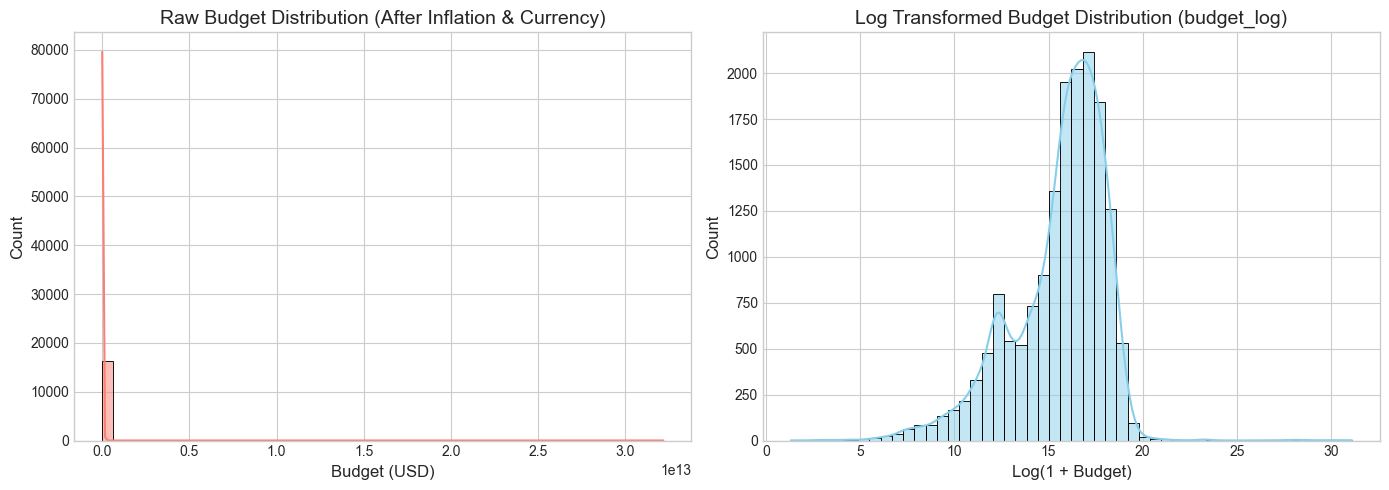

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# הגדרת סגנון הגרף
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# שליפת נתוני התקציב שעברו ניקוי (ללא ערכים חסרים)
clean_budgets = df_processed['budget_parsed'].dropna()

# יצירת משתנה הלוגריתם
log_budgets = np.log1p(clean_budgets)

# גרף 1: התפלגות מקורית (מוטה מאוד ימינה)
sns.histplot(clean_budgets, bins=50, ax=axes[0], color='salmon', kde=True)
axes[0].set_title('Raw Budget Distribution (After Inflation & Currency)', fontsize=14)
axes[0].set_xlabel('Budget (USD)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].ticklabel_format(style='sci', axis='x', scilimits=(0,0)) # תצוגה מדעית למספרים גדולים

# גרף 2: התפלגות אחרי טרנספורמציית הלוגריתם (דומה לנורמלית)
sns.histplot(log_budgets, bins=50, ax=axes[1], color='skyblue', kde=True)
axes[1].set_title('Log Transformed Budget Distribution (budget_log)', fontsize=14)
axes[1].set_xlabel('Log(1 + Budget)', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

In [10]:
# ==============================================================================
# תא 10: ניתוח שגיאות (Error Analysis) - חילוץ Over/Under Predictions
# ==============================================================================
from sklearn.model_selection import cross_val_predict

print("🔍 מחלץ תחזיות עבור כל סרט באמצעות Cross-Validation...")
# נשתמש במודל ה-Random Forest (rf_pipeline) בהנחה שהוא הטוב יותר. 
# אם ה-ElasticNet ניצח, תשנה כאן ל-elastic_pipeline
predictions = cross_val_predict(rf_pipeline, X, y, cv=cv_strategy, n_jobs=-1)

# יצירת דאטה-פריים להשוואה בין התחזית לאמת
error_df = pd.DataFrame({
    'tconst': raw_df.loc[X.index, 'tconst'], # מזהה הסרט כדי שנוכל לחפש את השם שלו
    'primaryTitle': raw_df.loc[X.index, 'primaryTitle'], # שם הסרט המקורי
    'startYear': raw_df.loc[X.index, 'startYear'],
    'Actual_Rating': y,
    'Predicted_Rating': predictions
})

# חישוב השגיאה (Residuals)
# שגיאה חיובית = המודל חזה יותר מדי (Overprediction)
# שגיאה שלילית = המודל חזה מעט מדי (Underprediction)
error_df['Error'] = error_df['Predicted_Rating'] - error_df['Actual_Rating']

# מציאת 10 הסרטים עם ה-Overprediction הגדול ביותר
# אלו סרטים שהמודל חשב שהם "שוברי קופות מצוינים" (לפי השחקנים/תקציב) אבל בפועל הם היו גרועים
top_10_over = error_df.sort_values(by='Error', ascending=False).head(10)

# מציאת 10 הסרטים עם ה-Underprediction הגדול ביותר
# אלו סרטים "פנינים נסתרות" שהמודל זלזל בהם (אולי כי הם ישנים או ללא קאסט מוכר), אבל הקהל אהב
top_10_under = error_df.sort_values(by='Error', ascending=True).head(10)

# הדפסה יפה לטובת הדוח
print("\n" + "="*80)
print(" 🛑 TOP 10 OVER-PREDICTIONS (המודל נתן ציון גבוה מדי)")
print("="*80)
display(top_10_over[['primaryTitle', 'startYear', 'Actual_Rating', 'Predicted_Rating', 'Error']].round(2))

print("\n" + "="*80)
print(" 💎 TOP 10 UNDER-PREDICTIONS (המודל נתן ציון נמוך מדי)")
print("="*80)
display(top_10_under[['primaryTitle', 'startYear', 'Actual_Rating', 'Predicted_Rating', 'Error']].round(2))

🔍 מחלץ תחזיות עבור כל סרט באמצעות Cross-Validation...

 🛑 TOP 10 OVER-PREDICTIONS (המודל נתן ציון גבוה מדי)


,primaryTitle,startYear,Actual_Rating,Predicted_Rating,Error
12464,Justin Bieber: Always Believing,2012.0,1.0,7.25,6.25
84225,Zoo School,2019.0,1.1,7.14,6.04
96377,At the Back of the Screen,2020.0,1.5,7.48,5.98
16815,Kurz,2023.0,1.2,7.15,5.95
45946,Play in the Gray,2009.0,1.3,7.18,5.88
72010,Tribalism Is Killing Us,2019.0,1.3,7.14,5.84
52582,Rape of the Soul,2006.0,1.7,7.53,5.83
52638,Ramo Trip,2012.0,1.4,7.20,5.80
5086,Justin Bieber: Never Say Never,2011.0,1.7,7.50,5.80
84069,Zwischen Glück und Krone,1959.0,1.2,6.97,5.77



 💎 TOP 10 UNDER-PREDICTIONS (המודל נתן ציון נמוך מדי)


,primaryTitle,startYear,Actual_Rating,Predicted_Rating,Error
106898,Bukunja Tekunja Mitti: The Cannibals,2012.0,9.1,3.88,-5.22
57344,Son-nim-1 Cheo-beon-jjae I-ya-gi,2011.0,9.1,4.21,-4.89
131379,Halloween Deluxe,2019.0,9.1,4.26,-4.84
126718,Graves End,2005.0,8.3,3.63,-4.67
9295,Justicia Implacable,2023.0,9.5,5.01,-4.49
68152,Adinaasam Vellapokkam,2025.0,9.3,4.81,-4.49
110883,Colour Palette,2024.0,9.1,4.65,-4.45
122228,Hell Squad 2: Fresh Meat,2024.0,8.9,4.47,-4.43
36522,Oscuro by Rene Potter,2016.0,8.6,4.20,-4.40
110367,Controlled,2022.0,7.8,3.45,-4.35


In [11]:
# רשימת 5 הסרטים שבחרנו לניתוח
selected_movies = [
    'Justin Bieber: Never Say Never',
    'Tribalism Is Killing Us',
    'Bukunja Tekunja Mitti: The Cannibals',
    'Halloween Deluxe',
    'Justicia Implacable'
]

print("שולף נתונים טכניים לניתוח שגיאות:\n" + "="*50)

for movie in selected_movies:
    # חיפוש הסרט בדאטה הגולמי
    movie_data = raw_df[raw_df['primaryTitle'] == movie]
    
    if not movie_data.empty:
        row = movie_data.iloc[0]
        print(f"סרט: {movie}")
        print(f"ציון בפועל: {row.get('averageRating', 'N/A')} | כמות הצבעות (numVotes): {row.get('numVotes', 'N/A')}")
        print(f"תקציב גולמי: {row.get('budget', 'N/A')}")
        print(f"ז'אנרים: {row.get('genres', 'N/A')}")
        print(f"מדינה: {row.get('Country', 'N/A')} | שפה: {row.get('Language', 'N/A')}")
        print(f"קאסט (IDs): {str(row.get('lead_actors_ids', 'N/A'))[:60]}...")
        print("-" * 50)

שולף נתונים טכניים לניתוח שגיאות:
סרט: Justin Bieber: Never Say Never
ציון בפועל: 1.7 | כמות הצבעות (numVotes): 76601.0
תקציב גולמי: nan
ז'אנרים: Documentary,Music
מדינה: nan | שפה: nan
קאסט (IDs): nan...
--------------------------------------------------
סרט: Tribalism Is Killing Us
ציון בפועל: 1.3 | כמות הצבעות (numVotes): 221.0
תקציב גולמי: nan
ז'אנרים: ['Documentary']
מדינה: nan | שפה: nan
קאסט (IDs): nan...
--------------------------------------------------
סרט: Bukunja Tekunja Mitti: The Cannibals
ציון בפועל: 9.1 | כמות הצבעות (numVotes): 68.0
תקציב גולמי: nan
ז'אנרים: ['Action', 'Horror']
מדינה: nan | שפה: nan
קאסט (IDs): ['nm5005752', 'nm5006193', 'nm5006327', 'nm4256868', 'nm4257...
--------------------------------------------------
סרט: Halloween Deluxe
ציון בפועל: 9.1 | כמות הצבעות (numVotes): 29.0
תקציב גולמי: nan
ז'אנרים: Horror
מדינה: nan | שפה: nan
קאסט (IDs): nan...
--------------------------------------------------
סרט: Justicia Implacable
ציון בפועל: 9.5 | כמות הצבעות

In [ ]:
# ==============================================================================
# תא 11: השוואת חריגים (Outliers) בין שני המודלים (סעיף 5.3)
# ==============================================================================
import pandas as pd
from sklearn.model_selection import cross_val_predict

print("⏳ מחשב תחזיות לשני המודלים להשוואת שגיאות...")
# שימוש בשמות המדויקים מהמחברת שלך: rf_pipeline ו- pipeline
rf_preds = cross_val_predict(rf_pipeline, X, y, cv=cv_strategy, n_jobs=-1)
en_preds = cross_val_predict(pipeline, X, y, cv=cv_strategy, n_jobs=-1) 

# בניית טבלת השוואה מרכזית
df_comp = pd.DataFrame({
    'Title': raw_df.loc[X.index, 'primaryTitle'],
    'Actual': y,
    'RF_Pred': rf_preds,
    'EN_Pred': en_preds
})

# חישוב השגיאות לשני המודלים
df_comp['RF_Error'] = df_comp['RF_Pred'] - df_comp['Actual']
df_comp['EN_Error'] = df_comp['EN_Pred'] - df_comp['Actual']

# חילוץ 20 החריגים של Random Forest (10 מעל, 10 מתחת)
rf_outliers = pd.concat([
    df_comp.sort_values(by='RF_Error', ascending=False).head(10),
    df_comp.sort_values(by='RF_Error', ascending=True).head(10)
])

# חילוץ 20 החריגים של ElasticNet (10 מעל, 10 מתחת)
en_outliers = pd.concat([
    df_comp.sort_values(by='EN_Error', ascending=False).head(10),
    df_comp.sort_values(by='EN_Error', ascending=True).head(10)
])

# בדיקת חפיפות (Overlap)
rf_titles = set(rf_outliers['Title'])
en_titles = set(en_outliers['Title'])
overlap = rf_titles.intersection(en_titles)

print("\n" + "="*60)
print(f" 📊 סיכום השוואת מודלים (Outliers)")
print("="*60)
print(f"כמות סרטים חופפים בטופ 20 של שני המודלים: {len(overlap)}")
if len(overlap) > 0:
    print(f"דוגמאות לחופפים: {list(overlap)[:5]}")

print("\n🚀 מתי ElasticNet ניצח את Random Forest?")
for title in (rf_titles - en_titles):
    row = df_comp[df_comp['Title'] == title].iloc[0]
    if abs(row['EN_Error']) < abs(row['RF_Error']) - 0.5: # שיפור של לפחות חצי נקודה
        print(f"- {title} | טעות עץ (RF): {abs(row['RF_Error']):.2f} | טעות ליניארית (EN): {abs(row['EN_Error']):.2f}")

print("\n🌳 מתי Random Forest ניצח את ElasticNet?")
for title in (en_titles - rf_titles):
    row = df_comp[df_comp['Title'] == title].iloc[0]
    if abs(row['RF_Error']) < abs(row['EN_Error']) - 0.5:
        print(f"- {title} | טעות ליניארית (EN): {abs(row['EN_Error']):.2f} | טעות עץ (RF): {abs(row['RF_Error']):.2f}")

⏳ מחשב תחזיות לשני המודלים להשוואת שגיאות...


In [21]:
# ==============================================================================
# תא 11: השוואת חריגים (Outliers) בין שני המודלים (סעיף 5.3)
# ==============================================================================

# חישוב שגיאה מוחלטת כדי למצוא את 20 הטעויות הגדולות ביותר (ללא תלות בכיוון השגיאה)
df_comp['RF_Abs_Error'] = df_comp['RF_Error'].abs()
df_comp['EN_Abs_Error'] = df_comp['EN_Error'].abs()

# שליפת 20 הסרטים עם השגיאה המוחלטת הגדולה ביותר מכל מודל
rf_top_20 = df_comp.sort_values(by='RF_Abs_Error', ascending=False).head(20)
en_top_20 = df_comp.sort_values(by='EN_Abs_Error', ascending=False).head(20)

# המרה לקבוצות (Sets) של שמות סרטים לצורך פעולות חיתוך והשוואה
rf_titles = set(rf_top_20['Title'])
en_titles = set(en_top_20['Title'])

# מציאת הסרטים החופפים והלא-חופפים
overlapping_movies = rf_titles.intersection(en_titles)
non_overlapping_movies = (rf_titles - en_titles).union(en_titles - rf_titles)

# הדפסה נקייה וממוקדת לדוח
print("==================================================")
print(" 🎬 השוואת חריגים (Top 20 Outliers)")
print("==================================================")
print(f"✅ כמות סרטים חופפים (טעות זהה בשני המודלים): {len(overlapping_movies)}")
print(f"❌ כמות סרטים לא חופפים (טעות ייחודית למודל): {len(non_overlapping_movies)}")
print("-" * 50)
print("📋 רשימת הסרטים החופפים:")
for i, movie in enumerate(sorted(list(overlapping_movies)), 1):
    print(f"   {i}. {movie}")


NameError: name 'df_comp' is not defined

In [ ]:
# ==============================================================================
# תא 12: מבחן Levene למובהקות סטטיסטית (השוואת שונות) עבור הפיצ'רים הנבחרים
# ==============================================================================
import scipy.stats as stats
import pandas as pd

print("📊 מחשב מובהקות סטטיסטית (P-Values) עבור 3 המאפיינים המרכזיים לדוח...")

# רשימת 3 המאפיינים המייצגים שבחרנו להציג (מדינה, שפה, ומידע חסר)
selected_features = ['is_other_country', 'is_lang_Spanish', 'is_decade_unknown']

# שחזור שמות העמודות המקוריים על גבי המטריצה המעובדת
real_features = X.columns
df_features = pd.DataFrame(X_transformed[:, :len(real_features)], columns=real_features, index=X.index)

# הוספת עמודת תווית: מי מהמודלים ניצח בפער של לפחות חצי נקודה?
df_features['Winner'] = df_comp['Winner']

# סינון רק לסרטים בהם יש מנצח ברור (ללא תוצאות תיקו)
df_winners = df_features[df_features['Winner'].isin(['RF_Won', 'EN_Won'])]

results = []
for col in selected_features:
    if col in df_winners.columns:
        # הפרדת הנתונים לקבוצת הניצחון של היער מול קבוצת הניצחון של הלינארי
        rf_data = df_winners[df_winners['Winner'] == 'RF_Won'][col]
        en_data = df_winners[df_winners['Winner'] == 'EN_Won'][col]
        
        # הרצת מבחן Levene לבדיקת הבדל מובהק בשונות (Variance)
        stat, p_val = stats.levene(rf_data, en_data)
        
        results.append({
            'Feature': col,
            'Std_RF_Won': rf_data.std(),
            'Std_EN_Won': en_data.std(),
            'P_Value': p_val
        })

# יצירת טבלה מסודרת והדפסתה
final_p_val_df = pd.DataFrame(results)
display(final_p_val_df.round(4))

In [15]:
# ==============================================================================
# תא 14: Fairness Analysis (מודל Random Forest) - קוד מותאם אקדמית/תעשייתית
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error

# פונקציית עזר לחישוב גם RMSE וגם MAE
def calc_metrics(actual, pred):
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae = mean_absolute_error(actual, pred)
    return rmse, mae

print("================================================================")
print(" ⚖️ סעיף 6: Fairness Analysis (מודל Random Forest) - גרסה מתקדמת")
print("================================================================")

# ---------------------------------------------------------
# 1. טיפול מקצועי בז'אנרים (Multi-Label Parsing & Exploding)
# ---------------------------------------------------------
print("\n1. ביצועים לפי 5 הז'אנרים הנפוצים ביותר:")

# פונקציה חכמה לחילוץ ז'אנרים ממחרוזות מבולגנות לרשימות נקיות
def extract_genres_to_list(val):
    if pd.isna(val) or str(val).strip() == '':
        return []
    # מחיקת סוגריים ומרכאות, ופיצול חכם לפי פסיק
    clean_str = str(val).replace('[', '').replace(']', '').replace("'", "").replace('"', '')
    return [g.strip() for g in clean_str.split(',') if g.strip()]

# יצירת עמודת רשימות (Lists)
df_fairness['genres_list'] = df_fairness['genres'].apply(extract_genres_to_list)

# "פיצוץ" העמודה לשורות נפרדות עבור כל ז'אנר (הסטנדרט לניתוח Multi-label)
df_exploded = df_fairness.explode('genres_list')
df_exploded = df_exploded.dropna(subset=['genres_list'])

# מציאת 5 הז'אנרים הנפוצים ביותר
top_5_genres = df_exploded['genres_list'].value_counts().head(5).index.tolist()

for genre in top_5_genres:
    # סינון מתוך המאגר המפוצץ כדי לקבל בדיוק את כל הסרטים שמכילים את הז'אנר
    subset = df_exploded[df_exploded['genres_list'] == genre]
    if len(subset) > 0:
        rmse_val, mae_val = calc_metrics(subset['Actual'], subset['RF_Pred'])
        print(f"   - {genre:<12} (n={len(subset):,}): RMSE = {rmse_val:.3f} | MAE = {mae_val:.3f}")

# ---------------------------------------------------------
# 2. לפי מדינת מקור (US מול Non-US)
# ---------------------------------------------------------
print("\n2. ביצועים לפי מדינת מקור (US מול Non-US):")
mask_us = df_fairness['Country'].str.contains('United States', na=False)
subset_us = df_fairness[mask_us]
subset_non_us = df_fairness[~mask_us]

if len(subset_us) > 0:
    rmse_val, mae_val = calc_metrics(subset_us['Actual'], subset_us['RF_Pred'])
    print(f"   - ארצות הברית (n={len(subset_us):,}): RMSE = {rmse_val:.3f} | MAE = {mae_val:.3f}")

if len(subset_non_us) > 0:
    rmse_val, mae_val = calc_metrics(subset_non_us['Actual'], subset_non_us['RF_Pred'])
    print(f"   - מחוץ לארה\"ב (n={len(subset_non_us):,}): RMSE = {rmse_val:.3f} | MAE = {mae_val:.3f}")

# ---------------------------------------------------------
# 3. לפי עשור יציאה (שנות ה-90, ה-2000 וה-2010)
# ---------------------------------------------------------
print("\n3. ביצועים לפי עשור יציאה (1990, 2000, 2010):")
df_fairness['startYear'] = pd.to_numeric(df_fairness['startYear'], errors='coerce')
df_fairness['Decade'] = (df_fairness['startYear'] // 10) * 10
target_decades = [1990, 2000, 2010]

for decade in target_decades:
    subset = df_fairness[df_fairness['Decade'] == decade]
    if len(subset) > 0:
        rmse_val, mae_val = calc_metrics(subset['Actual'], subset['RF_Pred'])
        print(f"   - שנות ה-{decade} (n={len(subset):,}): RMSE = {rmse_val:.3f} | MAE = {mae_val:.3f}")

# ---------------------------------------------------------
# 4. לפי תקציב (שלישונים) - רק לסרטים עם תקציב ידוע
# ---------------------------------------------------------
print("\n4. ביצועים לפי תקציב (שלישונים - נמוך/בינוני/גבוה):")
df_fairness['budget_clean'] = pd.to_numeric(df_fairness['budget'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
with_budget = df_fairness[df_fairness['budget_clean'].notna()].copy()

if len(with_budget) > 0:
    with_budget['Budget_Tertile'] = pd.qcut(with_budget['budget_clean'], q=3, labels=['נמוך (Low)', 'בינוני (Medium)', 'גבוה (High)'])
    for tertile in ['נמוך (Low)', 'בינוני (Medium)', 'גבוה (High)']:
        subset = with_budget[with_budget['Budget_Tertile'] == tertile]
        if len(subset) > 0:
            rmse_val, mae_val = calc_metrics(subset['Actual'], subset['RF_Pred'])
            print(f"   - תקציב {tertile} (n={len(subset):,}): RMSE = {rmse_val:.3f} | MAE = {mae_val:.3f}")

# ---------------------------------------------------------
# 5. חסר נתונים מול מלא
# ---------------------------------------------------------
print("\n5. ביצועים לפי שלמות נתונים (תקציב חסר מול קיים):")
missing_budget = df_fairness[df_fairness['budget_clean'].isna()]

if len(with_budget) > 0:
    rmse_val, mae_val = calc_metrics(with_budget['Actual'], with_budget['RF_Pred'])
    print(f"   - תקציב תקין וידוע (n={len(with_budget):,}): RMSE = {rmse_val:.3f} | MAE = {mae_val:.3f}")

if len(missing_budget) > 0:
    rmse_val, mae_val = calc_metrics(missing_budget['Actual'], missing_budget['RF_Pred'])
    print(f"   - תקציב חסר (n={len(missing_budget):,}): RMSE = {rmse_val:.3f} | MAE = {mae_val:.3f}")

 ⚖️ סעיף 6: Fairness Analysis (מודל Random Forest) - גרסה מתקדמת

1. ביצועים לפי 5 הז'אנרים הנפוצים ביותר:
   - Drama        (n=58,460): RMSE = 1.032 | MAE = 0.783
   - Comedy       (n=33,316): RMSE = 1.103 | MAE = 0.840
   - Romance      (n=15,693): RMSE = 0.998 | MAE = 0.760
   - Action       (n=13,987): RMSE = 1.165 | MAE = 0.895
   - Documentary  (n=13,014): RMSE = 1.009 | MAE = 0.740

2. ביצועים לפי מדינת מקור (US מול Non-US):
   - ארצות הברית (n=21,134): RMSE = 0.937 | MAE = 0.710
   - מחוץ לארה"ב (n=94,426): RMSE = 1.124 | MAE = 0.855

3. ביצועים לפי עשור יציאה (1990, 2000, 2010):
   - שנות ה-1990 (n=10,213): RMSE = 1.030 | MAE = 0.796
   - שנות ה-2000 (n=17,555): RMSE = 1.121 | MAE = 0.850
   - שנות ה-2010 (n=33,605): RMSE = 1.159 | MAE = 0.875

4. ביצועים לפי תקציב (שלישונים - נמוך/בינוני/גבוה):
   - תקציב נמוך (Low) (n=5,489): RMSE = 1.014 | MAE = 0.786
   - תקציב בינוני (Medium) (n=5,425): RMSE = 1.006 | MAE = 0.765
   - תקציב גבוה (High) (n=5,241): RMSE = 0.987 | MAE = 0.75

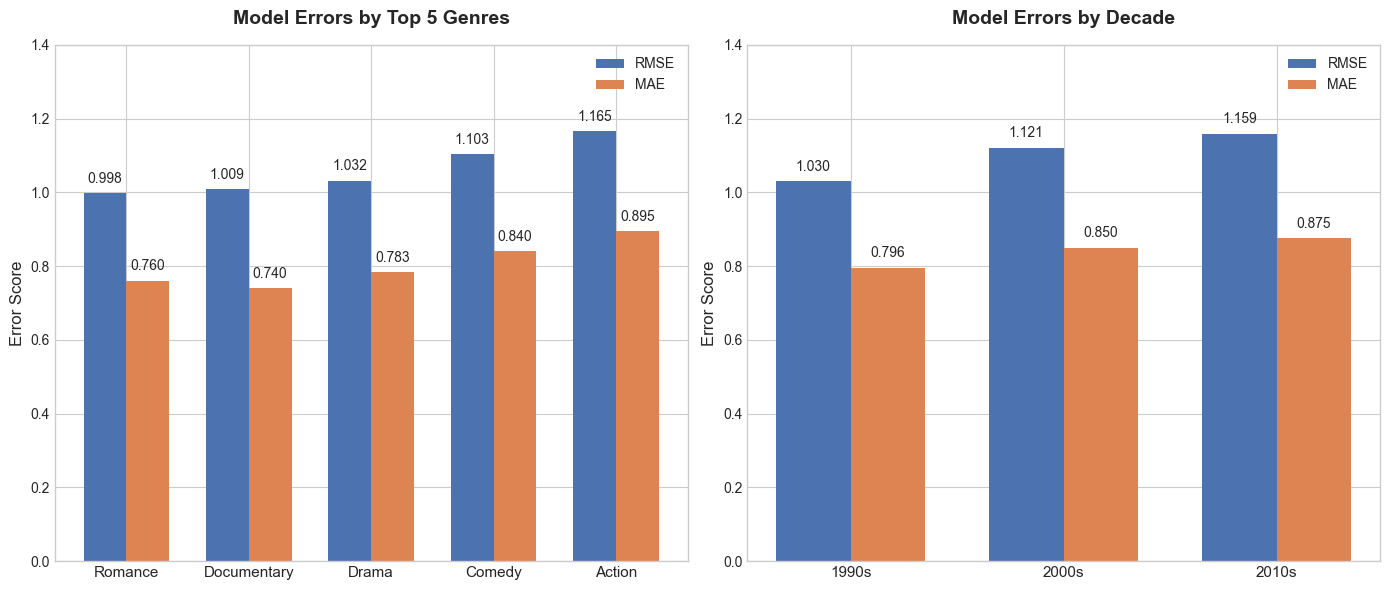

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. הגדרת הנתונים
# ==========================================

# נתוני ז'אנרים (ממוינים מהביצועים הטובים ביותר לגרועים ביותר)
genres_data = {
    'Category': ['Romance', 'Documentary', 'Drama', 'Comedy', 'Action'],
    'RMSE': [0.998, 1.009, 1.032, 1.103, 1.165],
    'MAE': [0.760, 0.740, 0.783, 0.840, 0.895]
}

# נתוני עשורים (ממוינים כרונולוגית)
decades_data = {
    'Category': ['1990s', '2000s', '2010s'],
    'RMSE': [1.030, 1.121, 1.159],
    'MAE': [0.796, 0.850, 0.875]
}

df_genres = pd.DataFrame(genres_data)
df_decades = pd.DataFrame(decades_data)

# ==========================================
# 2. עיצוב ויצירת הגרפים
# ==========================================

plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

width = 0.35 # עובי כל עמודה

# --- גרף 1: ז'אנרים ---
x1 = np.arange(len(df_genres['Category']))
axes[0].bar(x1 - width/2, df_genres['RMSE'], width, label='RMSE', color='#4C72B0')
axes[0].bar(x1 + width/2, df_genres['MAE'], width, label='MAE', color='#DD8452')

axes[0].set_title('Model Errors by Top 5 Genres', fontsize=14, pad=15, fontweight='bold')
axes[0].set_ylabel('Error Score', fontsize=12)
axes[0].set_xticks(x1)
axes[0].set_xticklabels(df_genres['Category'], fontsize=11)
axes[0].legend()
axes[0].set_ylim(0, 1.4)

# הוספת תוויות נתונים מעל העמודות (ז'אנרים)
for i in range(len(x1)):
    axes[0].text(x1[i] - width/2, df_genres['RMSE'][i] + 0.02, f"{df_genres['RMSE'][i]:.3f}", ha='center', va='bottom', fontsize=10)
    axes[0].text(x1[i] + width/2, df_genres['MAE'][i] + 0.02, f"{df_genres['MAE'][i]:.3f}", ha='center', va='bottom', fontsize=10)


# --- גרף 2: עשורים ---
x2 = np.arange(len(df_decades['Category']))
axes[1].bar(x2 - width/2, df_decades['RMSE'], width, label='RMSE', color='#4C72B0')
axes[1].bar(x2 + width/2, df_decades['MAE'], width, label='MAE', color='#DD8452')

axes[1].set_title('Model Errors by Decade', fontsize=14, pad=15, fontweight='bold')
axes[1].set_ylabel('Error Score', fontsize=12)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(df_decades['Category'], fontsize=11)
axes[1].legend()
axes[1].set_ylim(0, 1.4)

# הוספת תוויות נתונים מעל העמודות (עשורים)
for i in range(len(x2)):
    axes[1].text(x2[i] - width/2, df_decades['RMSE'][i] + 0.02, f"{df_decades['RMSE'][i]:.3f}", ha='center', va='bottom', fontsize=10)
    axes[1].text(x2[i] + width/2, df_decades['MAE'][i] + 0.02, f"{df_decades['MAE'][i]:.3f}", ha='center', va='bottom', fontsize=10)

# ==========================================
# 3. הצגת הגרף
# ==========================================
plt.tight_layout()
plt.show()

In [18]:
# ==============================================================================
# תא חקירת עומק לדיון: רעש, נתונים חסרים ואמינות המודל (עבור החתכים הנבחרים)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# וידוא שעמודות העזר קיימות
if 'genres_clean' not in df_fairness.columns:
    df_fairness['genres_clean'] = df_fairness['genres'].astype(str).str.replace(r"[\[\]'\"]", "", regex=True)
if 'budget_clean' not in df_fairness.columns:
    df_fairness['budget_clean'] = pd.to_numeric(df_fairness['budget'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
if 'Decade' not in df_fairness.columns:
    df_fairness['startYear'] = pd.to_numeric(df_fairness['startYear'], errors='coerce')
    df_fairness['Decade'] = (df_fairness['startYear'] // 10) * 10

# מדדי הבסיס (Global Metrics)
global_rmse = np.sqrt(mean_squared_error(df_fairness['Actual'], df_fairness['RF_Pred']))
global_noise = df_fairness['Actual'].std()
global_missing_budget = df_fairness['budget_clean'].isna().mean() * 100

print("==================================================")
print(" 🌍 מדדי בסיס (Global Metrics)")
print("==================================================")
print(f" - RMSE ממוצע כללי: {global_rmse:.3f}")
print(f" - רעש ממוצע (סטיית תקן של ציונים): {global_noise:.3f}")
print(f" - אחוז סרטים ללא תקציב מכלל הדאטה: {global_missing_budget:.1f}%")
print("==================================================\n")

def analyze_slice(slice_name, mask):
    subset = df_fairness[mask]
    if len(subset) == 0: return
    
    rmse = np.sqrt(mean_squared_error(subset['Actual'], subset['RF_Pred']))
    diff_pct = ((rmse - global_rmse) / global_rmse) * 100
    noise = subset['Actual'].std()
    missing_budget_pct = subset['budget_clean'].isna().mean() * 100
    
    print(f"🔍 חתך: {slice_name}")
    print(f"   • כמות (n): {len(subset):,}")
    print(f"   • שגיאה (RMSE): {rmse:.3f} ({diff_pct:+.1f}% ביחס לממוצע)")
    print(f"   • רעש (סטיית תקן הציונים בפועל): {noise:.3f}")
    print(f"   • אחוז סרטים ללא נתוני תקציב (Missingness): {missing_budget_pct:.1f}%")
    print("-" * 50)

# --- חמשת הז'אנרים הנפוצים ---
print(">>> חתכי ז'אנרים (Top 5) <<<")
analyze_slice("דרמה (Drama)", df_fairness['genres_clean'].str.contains('Drama', na=False))
analyze_slice("קומדיה (Comedy)", df_fairness['genres_clean'].str.contains('Comedy', na=False))
analyze_slice("רומנטיקה (Romance)", df_fairness['genres_clean'].str.contains('Romance', na=False))
analyze_slice("פעולה (Action)", df_fairness['genres_clean'].str.contains('Action', na=False))
analyze_slice("דוקומנטרי (Documentary)", df_fairness['genres_clean'].str.contains('Documentary', na=False))
print("\n")

# --- שלושת העשורים ---
print(">>> חתכי עשורים (1990, 2000, 2010) <<<")
analyze_slice("שנות ה-1990", df_fairness['Decade'] == 1990)
analyze_slice("שנות ה-2000", df_fairness['Decade'] == 2000)
analyze_slice("שנות ה-2010", df_fairness['Decade'] == 2010)
print("\n")

# --- שלמות נתונים (Missingness) ---
print(">>> חתכי שלמות נתונים (תקציב) <<<")
analyze_slice("יש נתוני תקציב (No Missingness)", df_fairness['budget_clean'].notna())
analyze_slice("אין נתוני תקציב (Missingness)", df_fairness['budget_clean'].isna())

 🌍 מדדי בסיס (Global Metrics)
 - RMSE ממוצע כללי: 1.093
 - רעש ממוצע (סטיית תקן של ציונים): 1.293
 - אחוז סרטים ללא תקציב מכלל הדאטה: 86.0%

>>> חתכי ז'אנרים (Top 5) <<<
🔍 חתך: דרמה (Drama)
   • כמות (n): 58,460
   • שגיאה (RMSE): 1.032 (-5.6% ביחס לממוצע)
   • רעש (סטיית תקן הציונים בפועל): 1.127
   • אחוז סרטים ללא נתוני תקציב (Missingness): 85.1%
--------------------------------------------------
🔍 חתך: קומדיה (Comedy)
   • כמות (n): 33,316
   • שגיאה (RMSE): 1.103 (+0.9% ביחס לממוצע)
   • רעש (סטיית תקן הציונים בפועל): 1.209
   • אחוז סרטים ללא נתוני תקציב (Missingness): 83.7%
--------------------------------------------------
🔍 חתך: רומנטיקה (Romance)
   • כמות (n): 15,693
   • שגיאה (RMSE): 0.998 (-8.7% ביחס לממוצע)
   • רעש (סטיית תקן הציונים בפועל): 1.071
   • אחוז סרטים ללא נתוני תקציב (Missingness): 83.4%
--------------------------------------------------
🔍 חתך: פעולה (Action)
   • כמות (n): 13,987
   • שגיאה (RMSE): 1.165 (+6.7% ביחס לממוצע)
   • רעש (סטיית תקן הציונים בפועל

In [20]:
# ==============================================================================
# תא 15: חילוץ Feature Importance וכיוון השפעה לשני המודלים (סעיף 7) - מתוקן
# ==============================================================================
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("⏳ מאמן מודלים ומושך חשיבויות פיצ'רים (ייקח מספר שניות)...")

# 1. אימון המודלים על כל המידע כדי לקבל את המקדמים המדויקים ביותר
rf_pipeline.fit(X, y)
pipeline.fit(X, y)

# 2. חילוץ חכם של שמות העמודות (פותר את ה-AttributeError של Numpy)
temp_df = X.head(2).copy()
feature_names = temp_df.columns.tolist()

# נעבור שלב-שלב ונשמור את השמות מהשלב האחרון שעדיין מתנהג כמו טבלה
for name, step in pipeline[:-1].steps:
    temp_df = step.transform(temp_df)
    if isinstance(temp_df, pd.DataFrame):
        feature_names = temp_df.columns.tolist()

# נעביר את כל הנתונים לעיבוד ונחזיר אותם בחזרה להיות טבלה עם השמות שמצאנו
X_full_transformed_np = pipeline[:-1].transform(X)
X_full_transformed = pd.DataFrame(X_full_transformed_np, columns=feature_names, index=X.index)

# ==========================================
# Elastic Net Analysis (לינארי)
# ==========================================
en_model = pipeline.steps[-1][1]
en_coefs = en_model.coef_

df_en = pd.DataFrame({'Feature': feature_names, 'Coef': en_coefs})
df_en['Abs_Coef'] = df_en['Coef'].abs()
# טופ 5 לפי גודל מוחלט
top_en = df_en.sort_values(by='Abs_Coef', ascending=False).head(5).copy()
top_en['Direction'] = np.where(top_en['Coef'] > 0, 'חיובי (+)', 'שלילי (-)')

# ==========================================
# Random Forest Analysis (עץ)
# ==========================================
rf_model = rf_pipeline.steps[-1][1]
rf_importances = rf_model.feature_importances_

df_rf = pd.DataFrame({'Feature': feature_names, 'Importance': rf_importances})
top_rf = df_rf.sort_values(by='Importance', ascending=False).head(5).copy()

# יער אקראי לא מספק כיוון ישירות. נחשב קורלציה (מתאם פירסון) מול התוצאה
directions = []
for feat in top_rf['Feature']:
    corr = np.corrcoef(X_full_transformed[feat].fillna(0), y)[0, 1]
    directions.append('חיובי (+)' if corr > 0 else 'שלילי (-)')
top_rf['Direction'] = directions

# ==========================================
# הדפסת התוצאות
# ==========================================
print("=======================================================")
print(" 📉 טופ 5 פיצ'רים - מודל לינארי (Elastic Net)")
print("=======================================================")
for idx, row in top_en.iterrows():
    print(f" - {row['Feature']:<25} | מקדם: {row['Coef']:>7.4f} | כיוון השפעה: {row['Direction']}")

print("\n=======================================================")
print(" 🌲 טופ 5 פיצ'רים - מודל עץ (Random Forest)")
print("=======================================================")
for idx, row in top_rf.iterrows():
    print(f" - {row['Feature']:<25} | חשיבות: {row['Importance']:>7.4f} | כיוון השפעה: {row['Direction']}")

⏳ מאמן מודלים ומושך חשיבויות פיצ'רים (ייקח מספר שניות)...
 📉 טופ 5 פיצ'רים - מודל לינארי (Elastic Net)
 - cast_mean                 | מקדם: -0.7037 | כיוון השפעה: שלילי (-)
 - genre_target_encoded      | מקדם:  0.5369 | כיוון השפעה: חיובי (+)
 - cast_max                  | מקדם:  0.4985 | כיוון השפעה: חיובי (+)
 - cast_min                  | מקדם:  0.4537 | כיוון השפעה: חיובי (+)
 - runtimeMinutes_sq         | מקדם:  0.1406 | כיוון השפעה: חיובי (+)

 🌲 טופ 5 פיצ'רים - מודל עץ (Random Forest)
 - genre_target_encoded      | חשיבות:  0.4808 | כיוון השפעה: חיובי (+)
 - cast_mean                 | חשיבות:  0.2460 | כיוון השפעה: חיובי (+)
 - cast_experience_log       | חשיבות:  0.0341 | כיוון השפעה: חיובי (+)
 - cast_min                  | חשיבות:  0.0288 | כיוון השפעה: חיובי (+)
 - runtimeMinutes_cu         | חשיבות:  0.0265 | כיוון השפעה: חיובי (+)
